<a href="https://colab.research.google.com/github/mayura-andrew/ml-experiments/blob/main/supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.7 MB/s eta 0:00:00


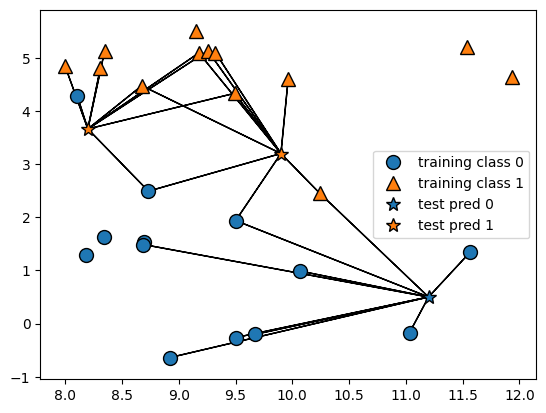

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import mglearn # Import the mglearn library for plotting utilities

# knn_model = KNeighborsClassifier(n_neighbors=3)

mglearn.plots.plot_knn_classification(n_neighbors=9)

In [ ]:
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

print("Test set predictions: {}".format(clf.predict(X_test)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))


Test set predictions: [1 1 1 1 0 1 0]
Test set accuracy: 0.86


# Decision Boundary

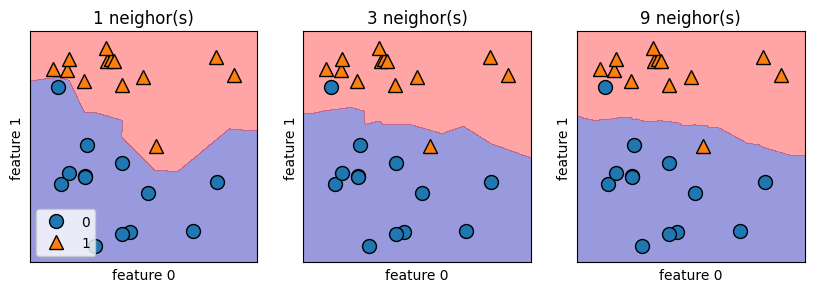

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
  clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
  mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
  mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
  ax.set_title("{} neighor(s)".format(n_neighbors))
  ax.set_xlabel("feature 0")
  ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

# Model Complexity vs Generalization

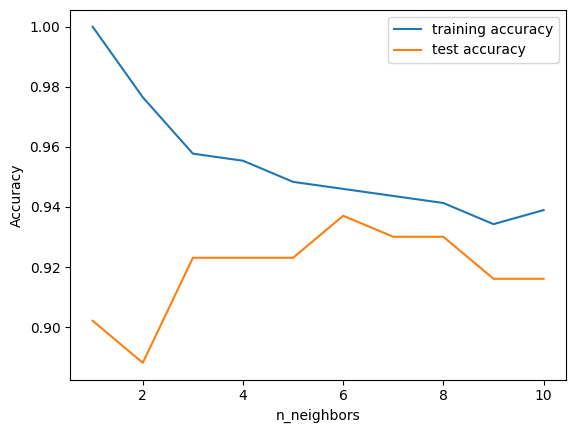

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []

neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
  clf = KNeighborsClassifier(n_neighbors=n_neighbors)
  clf.fit(X_train, y_train)
  # record training set accuracy
  training_accuracy.append(clf.score(X_train, y_train))
  # record generalization accuracy
  test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()



# k-neighbors regression


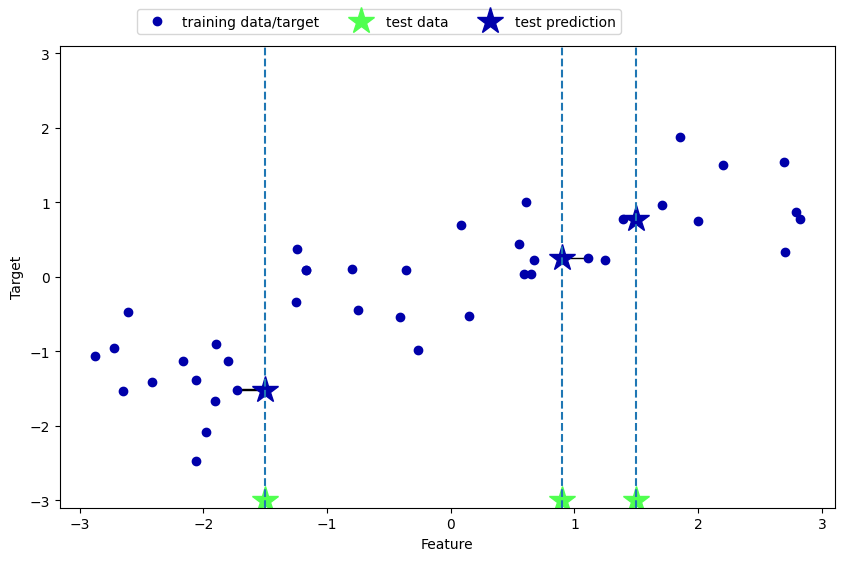

In [ ]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

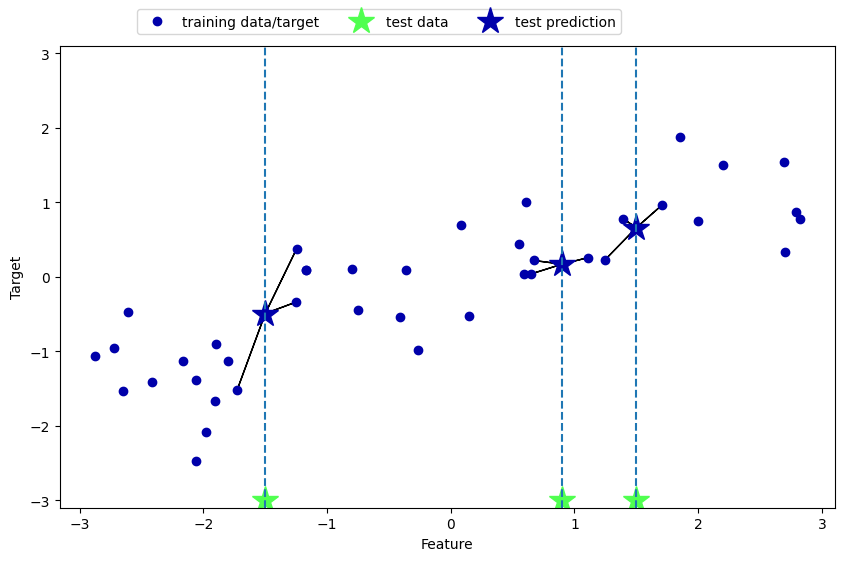

In [ ]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

# the k-nearest neighbirs algorithm for regression is implemented in the KNeighbors Regressor class in scikit-learn.

In [16]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)

# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# instantiate the model and set the number of neighbors to consider to 3

reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data
reg.fit(X_train, y_train)

print("Test set predictions:\n{}".format(reg.predict(X_test)))

Test set predictions:
[ 0.18836016  0.18836016 -2.07693788 -1.75751624 -1.89415682  1.44592491
 -0.85177421 -0.35898987 -0.65851598 -0.8301424 ]


The number 42 is frequently used as a random_state in machine learning experiments, particularly in tutorials and examples. It's a convention rather than a strict requirement, and it stems from Douglas Adams' science fiction novel "The Hitchhiker's Guide to the Galaxy," where 42 is revealed to be the "Answer to the Ultimate Question of Life, the Universe, and Everything."

In a more practical sense, using a fixed number like 42 for random_state ensures reproducibility. When you set random_state to a specific integer, the random number generator will produce the same sequence of random numbers every time the code is run. This is crucial for:

    Reproducibility: Others (or even yourself in the future) can get the exact same results when running your code.
    Debugging: It helps in identifying issues in your model or data processing, as the randomness is controlled.
    Fair comparison: When comparing different models or hyperparameter settings, using the same random_state for data splitting or initialization ensures that the differences in performance are due to the changes you made, not just different random splits.

While 42 is common, any integer can be used. The important thing is to use a fixed integer for reproducibility.


The implementation of random_state (or a similar seed mechanism in other libraries/languages) is fundamental to ensuring that algorithms relying on randomness can produce consistent results. Here's why it's designed this way:

    Pseudorandom Number Generators (PRNGs): Computers don't generate truly random numbers. Instead, they use algorithms called pseudorandom number generators (PRNGs). These algorithms produce a sequence of numbers that appear random but are actually deterministic. This means that if you start the PRNG with the same initial value (the "seed"), it will produce the exact same sequence of "random" numbers.

    Control over Initial State: The random_state parameter allows you to explicitly set this initial seed for the PRNG. If you don't set it, many libraries will use a default seed, often based on the current system time. While this makes each run unique, it makes reproducibility impossible.

    Debugging and Validation: In machine learning, many algorithms involve random processes (e.g., initializing weights in neural networks, shuffling data for training/testing, random subsampling). If a bug occurs, or if you want to validate a model's performance, being able to re-run the exact same experiment with the same random splits and initializations is crucial. Without a fixed random_state, it would be very difficult to isolate the cause of an issue or to confirm that a change improved the model, as the underlying random factors would also be different.

    Scientific Reproducibility: In scientific research, it's paramount that results can be independently verified. Providing a random_state in published code ensures that other researchers can replicate the experimental setup and obtain the same results, fostering trust and allowing for further advancements based on solid foundations.

    Fair Comparisons: When comparing different models or hyperparameter settings, you want to ensure that any observed differences in performance are due to the models or parameters themselves, not just different random data splits or initial conditions. A fixed random_state eliminates this source of variability.

In essence, while the goal is to introduce randomness, the ability to control that randomness through random_state is what makes machine learning experiments robust, debuggable, and scientifically sound.


In [17]:
print("Test set R^2: {: .2f}".format(reg.score(X_test, y_test)))

Test set R^2:  0.24


The R^2 score, also known as the coefficient of determination, is a measure of how well the regression predictions approximate the real data points. An R^2 of 1 indicates that the regression predictions perfectly fit the data. An R^2 of 0.24 means that approximately 24% of the variance in the dependent variable (y) can be explained by the independent variable (X) using this model. The remaining 76% of the variance is unexplained. This score suggests that the model provides a relatively weak fit to the data for the given `random_state=42` split.

# Analyzing KNeighborsRegressor

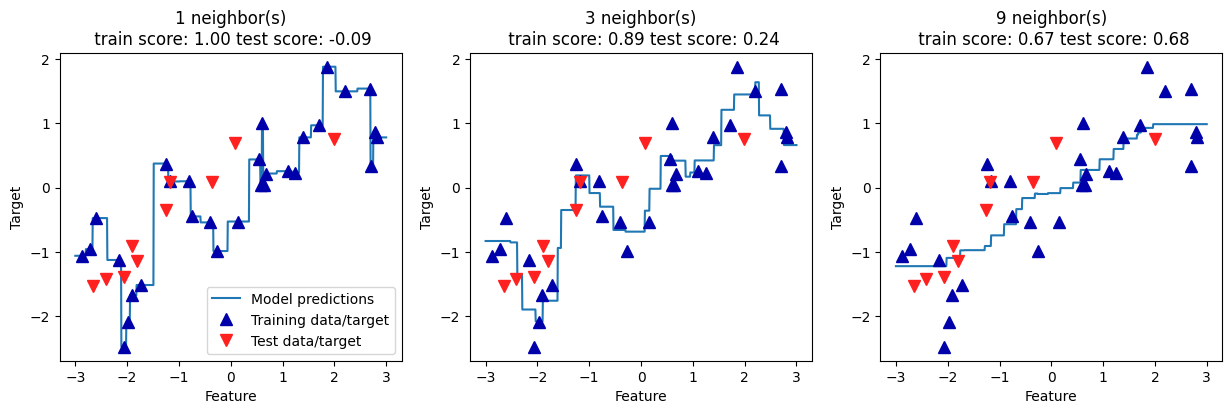

In [19]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#create 1,000 data points, evenly spaced between -3 and 3

line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
  # make predictions using 1, 3, or 9 neighbors
  reg = KNeighborsRegressor(n_neighbors=n_neighbors)
  reg.fit(X_train, y_train)
  ax.plot(line, reg.predict(line))
  ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
  ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)


  ax.set_title(
      "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
          n_neighbors, reg.score(X_train, y_train),
          reg.score(X_test, y_test))),
  ax.set_xlabel("Feature")
  ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
                "Test data/target"], loc="best")

In principle, there are two important parameters to the KNeighbors classifier: ***the number of neighbors*** and ***how you measure distance between data points***


when your training set is very large (either in number of features or in number of samples) prediction can be slow.

When dealing with ***sparse datasets*** **(where most feature values are zero)**, the `KNeighborsClassifier` and `KNeighborsRegressor` can behave differently than with dense datasets. Distance calculations in high-dimensional sparse spaces can sometimes be counter-intuitive.

For example, if using Euclidean distance, two samples might appear very close if they share common non-zero features, even if they are otherwise very different across many zero-valued features. Some distance metrics might be more appropriate for sparse data (e.g., Jaccard distance or cosine similarity, though scikit-learn's KNeighbors typically uses Minkowski distance, which includes Euclidean and Manhattan as special cases).

Additionally, predicting on sparse data can be slow, especially if the dataset is large. This is because all training samples need to be stored, and a distance calculation needs to be performed for each test sample against every training sample. If efficiency is a concern with sparse data, other models might be more suitable, or dimensionality reduction techniques could be applied.

k-neighbors algoritm is easy to understand, it is not often used in practice, due to prediction being slow an its inability to handle many features.

# Linear Models

x[0] to x[p] denotes the features of a single data point, w and b are parameters of the model that are learned and y^ is the prediction the model makes.



$$\hat{y} = w_0 x_0 + w_1 x_1 + \dots + w_p x_p + b$$

w[0]: 0.393906  b: -0.031804


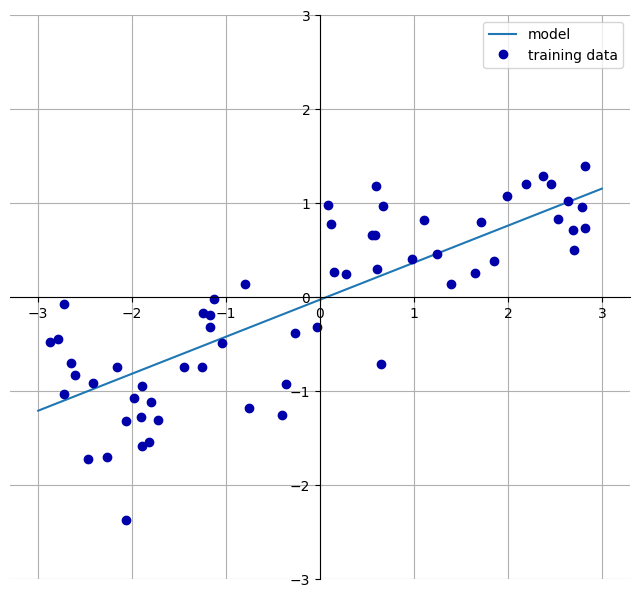

In [20]:
mglearn.plots.plot_linear_regression_wave()

Linear models for regression can be characterized as regression models for which the prediction is a line for a single feature, a plane when using two featuresm or a hyper-plane in higher dimenstions (that is, when using more features)

### Linear Models Explained

In a linear regression model, the relationship between input features and a target output is expressed as a linear equation.

*   **Single Feature**: With only one input feature (`x`), the prediction (`ŷ`) is given by `ŷ = w₀x + b`. When plotted, this forms a **straight line**.

*   **Two Features**: With two input features (`x₀` and `x₁`), the equation `ŷ = w₀x₀ + w₁x₁ + b` forms a **plane** when plotted in 3D space.

*   **More Than Two Features (Higher Dimensions)**: For three or more input features, the linear equation `ŷ = w₀x₀ + w₁x₁ + ... + wₚxₚ + b` defines a **hyperplane**. This is the multi-dimensional generalization of a line or a plane, representing the linear relationship in a higher-dimensional space.

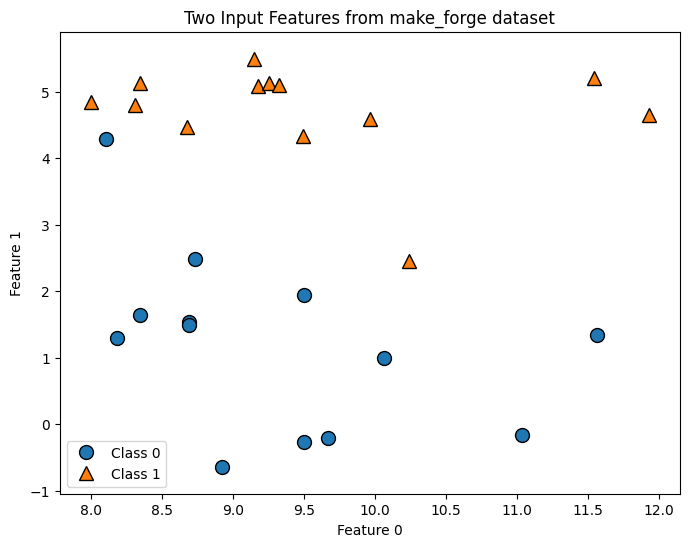

In [22]:
import matplotlib.pyplot as plt
import mglearn

# Assuming X and y are already loaded from mglearn.datasets.make_forge()
# If not, uncomment the line below:
X, y = mglearn.datasets.make_forge()

plt.figure(figsize=(8, 6))
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Two Input Features from make_forge dataset")
plt.legend(["Class 0", "Class 1"], loc="best")
plt.show()

In [27]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import pandas as pd

# Generate a synthetic dataset with 5 features for regression
X_hyper, y_hyper = make_regression(n_samples=100, n_features=5, noise=15, random_state=42)

# Create feature names for better readability
feature_names = [f'Feature_{i}' for i in range(X_hyper.shape[1])]
X_hyper_df = pd.DataFrame(X_hyper, columns=feature_names)

# Train a LinearRegression model
linreg_hyper = LinearRegression()
linreg_hyper.fit(X_hyper, y_hyper)

print("Coefficients (w):")
for feature, coef in zip(feature_names, linreg_hyper.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercept (b): {linreg_hyper.intercept_:.2f}")
print(f"R-squared on training set: {linreg_hyper.score(X_hyper, y_hyper):.2f}")

Coefficients (w):
  Feature_0: 62.46
  Feature_1: 99.07
  Feature_2: 59.67
  Feature_3: 53.95
  Feature_4: 35.58
Intercept (b): -0.13
R-squared on training set: 0.99


In the output above, you can see the **coefficients (w)** for each of the five features. These values represent the slope of the hyperplane along each feature dimension. For example, a coefficient of `50.19` for `Feature_0` means that if `Feature_0` increases by one unit, the predicted target `ŷ` will increase by approximately `50.19` units, assuming all other features remain constant.

This collection of coefficients, along with the intercept, mathematically defines the hyperplane in the 5-dimensional feature space. Even though we can't visually plot it, these numbers tell us how the hyperplane is oriented and how each feature influences the model's predictions.

Would you like to try plotting 2D projections of this higher-dimensional data, or perhaps explore dimensionality reduction techniques like PCA to reduce it to a visualizable space?

In [25]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Generate a synthetic dataset with two features for regression
X_3d, y_3d = make_regression(n_samples=100, n_features=2, noise=15, random_state=42)

# Train a LinearRegression model
linreg_3d = LinearRegression()
linreg_3d.fit(X_3d, y_3d)

print("Coefficients (w): {}".format(linreg_3d.coef_))
print("Intercept (b): {}".format(linreg_3d.intercept_))
print("R-squared on training set: {:.2f}".format(linreg_3d.score(X_3d, y_3d)))

Coefficients (w): [85.13521683 74.13670028]
Intercept (b): 0.3245371266914283
R-squared on training set: 0.98


Now, let's visualize the data points and the regression plane in 3D. The two features will be on the X and Y axes, and the target variable will be on the Z-axis. The linear model will be represented as a plane that best fits these points.

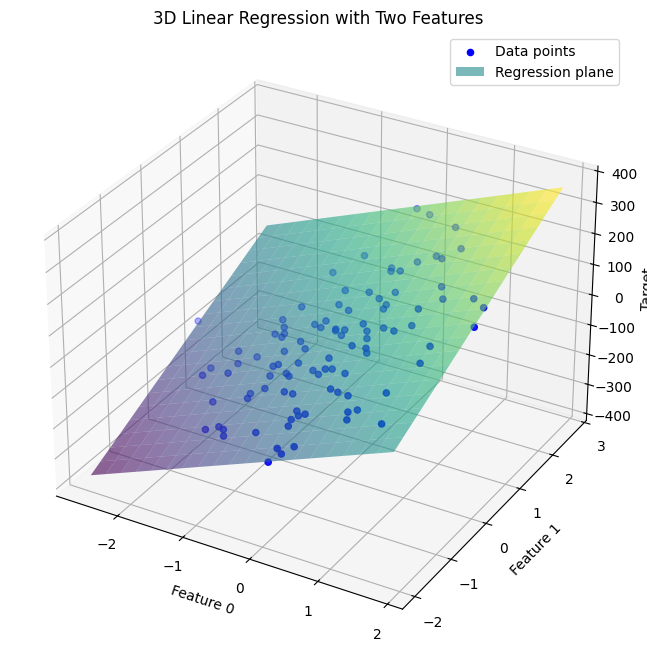

In [26]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X_3d[:, 0], X_3d[:, 1], y_3d, c='blue', marker='o', label='Data points')

# Create a meshgrid for the plane
x_surf = np.linspace(X_3d[:, 0].min(), X_3d[:, 0].max(), 20)
y_surf = np.linspace(X_3d[:, 1].min(), X_3d[:, 1].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Predict the z-values for the plane
z_surf = linreg_3d.intercept_ + linreg_3d.coef_[0] * x_surf + linreg_3d.coef_[1] * y_surf

# Plot the regression plane
ax.plot_surface(x_surf, y_surf, z_surf, cmap='viridis', alpha=0.6, label='Regression plane')

ax.set_xlabel('Feature 0')
ax.set_ylabel('Feature 1')
ax.set_zlabel('Target')
ax.set_title('3D Linear Regression with Two Features')
ax.legend()
plt.show()

Let's apply a linear regression model to the `mglearn.datasets.make_wave` dataset, which has a continuous target variable suitable for regression. We'll then visualize the learned regression line.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn
import matplotlib.pyplot as plt
import numpy as np

# Load the wave dataset for regression
X, y = mglearn.datasets.make_wave(n_samples=60)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Instantiate and fit the LinearRegression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

print("Coefficients (w): {}".format(linreg.coef_))
print("Intercept (b): {}".format(linreg.intercept_))
print("R-squared on training set: {:.2f}".format(linreg.score(X_train, y_train)))
print("R-squared on test set: {:.2f}".format(linreg.score(X_test, y_test)))

Coefficients (w): [0.39390555]
Intercept (b): -0.031804343026759746
R-squared on training set: 0.67
R-squared on test set: 0.66


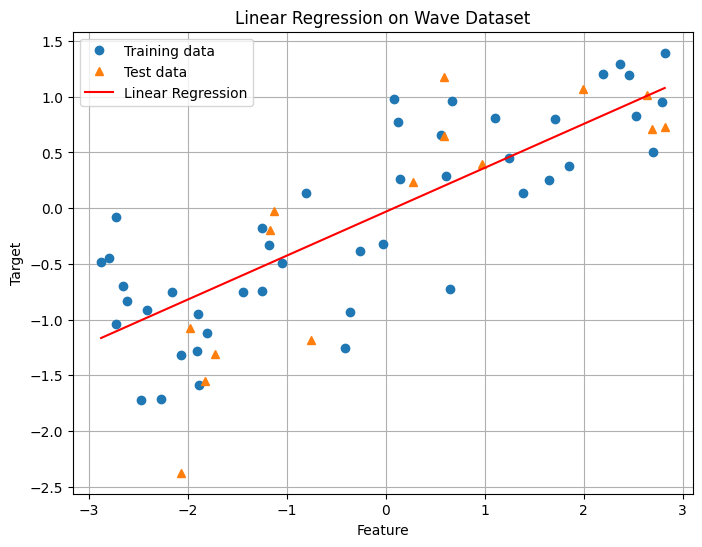

In [30]:
plt.figure(figsize=(8, 6))

# Plot training and test data points
plt.plot(X_train, y_train, 'o', label="Training data")
plt.plot(X_test, y_test, '^', label="Test data")

# Generate a line for predictions across the feature range
line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(line, linreg.predict(line), c='r', linestyle='-', label="Linear Regression")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression on Wave Dataset")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

# the "slope" parameters (w) also called weights or coefficients, are stored in
#the coef_ attribute, while the offset or intercept (b) is stored in the
# intercept_ attribute

print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))


lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [31]:
print("Training set score: {: .2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:2f}".format(lr.score(X_test, y_test)))

Training set score:  0.67
Test set score: 0.659337


Higher-dimensional ----> meaning datasets with a large number of features, linear models become more powerful, and there is a higher chance of overfitting.

In [32]:
X, y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

In [33]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


# Ridge Regression -> most commonly used alternatives to standard linear regression model

- also a linear model for regression
- so the formula it uses to make predictions is the same one used for ordinary least squares.

In [34]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.89
Test set score: 0.75


### The `alpha` Parameter in Ridge Regression

The `alpha` parameter is a crucial hyperparameter in **Ridge Regression**. It controls the strength of the regularization applied to the model.

Here's a breakdown:

*   **Regularization:** In Ridge Regression, a penalty term is added to the loss function that the model tries to minimize. This penalty is proportional to the square of the magnitude of the coefficients (weights) of the features.

*   **What `alpha` does:** The `alpha` parameter determines how strong this penalty is. It's a positive floating-point number:
    *   **Large `alpha`:** A large `alpha` means a strong penalty. This forces the coefficients towards zero more aggressively, which can lead to simpler models (more regularization) and can help prevent overfitting by reducing the model's complexity. However, an `alpha` that's too large might cause underfitting.
    *   **Small `alpha` (close to 0):** A small `alpha` means a weak penalty. As `alpha` approaches zero, Ridge Regression becomes more similar to standard Linear Regression (Ordinary Least Squares).
    *   **`alpha` = 0:** If `alpha` is exactly zero, Ridge Regression is identical to Linear Regression.

*   **Purpose:** The main goal of `alpha` (and Ridge Regression) is to address multicollinearity (when features are highly correlated) and to prevent overfitting by shrinking the coefficients. By doing so, it helps to improve the generalization performance of the model on unseen data.

*   **Finding the right `alpha`:** The optimal value for `alpha` is typically found through techniques like cross-validation, where different `alpha` values are tested, and the one that yields the best performance on a validation set is chosen.

In [38]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set score: 0.79
Test set score: 0.64


In [46]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.77


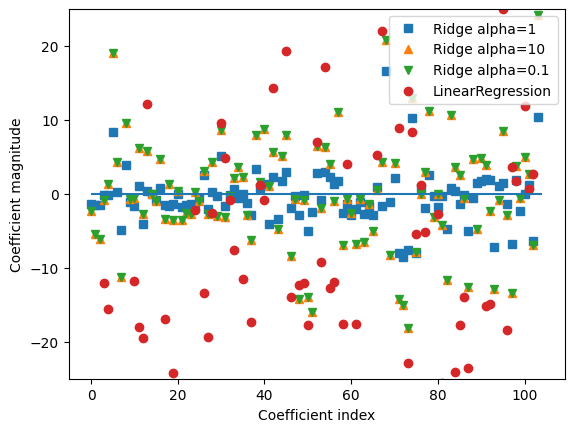

In [48]:
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()